# Homework 2: Implement a Simplified Decoder-Only Transformer

## Starter Notebook

Complete all TODO sections. Upload toy_transformer_corpus.txt to your Google Colab session before running the data-preparation cells. The helper file decoder_skeleton.py contains the same core skeleton as a separate reference.

Do not submit this starter unchanged. Rename your completed notebook:

~~~text
LastName_FirstName_Homework2.ipynb
~~~

## Setup

In [16]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 1: Load the Corpus and Create Next-Token Examples

Upload the provided text file to Colab by using the Files panel on the left, then run this cell. Inspect all printed shapes and answer the written questions in the assignment description.

In [18]:
corpus_path = Path("toy_transformer_corpus.txt")
if not corpus_path.exists():
    raise FileNotFoundError(
        "Upload toy_transformer_corpus.txt to the current Colab session, then rerun this cell."
    )

text = corpus_path.read_text(encoding="utf-8").lower()
tokens = text.split()

special_tokens = ["<pad>", "<unk>"]
vocabulary = special_tokens + sorted(set(tokens))
word_to_id = {word: index for index, word in enumerate(vocabulary)}
id_to_word = {index: word for word, index in word_to_id.items()}

PAD_ID = word_to_id["<pad>"]
UNK_ID = word_to_id["<unk>"]
vocab_size = len(vocabulary)
encoded_tokens = torch.tensor([word_to_id.get(word, UNK_ID) for word in tokens])

context_length = 8
inputs, targets = [], []
for start in range(len(encoded_tokens) - context_length):
    inputs.append(encoded_tokens[start:start + context_length])
    targets.append(encoded_tokens[start + 1:start + context_length + 1])

X = torch.stack(inputs)
y = torch.stack(targets)

indices = torch.randperm(len(X))
split = int(0.8 * len(X))
train_indices, val_indices = indices[:split], indices[split:]
X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

print("Vocabulary size:", vocab_size)
print("Input shape:", tuple(X.shape))
print("Target shape:", tuple(y.shape))
example_x, example_y = next(iter(train_loader))
print("Input batch shape:", tuple(example_x.shape))
print("Target batch shape:", tuple(example_y.shape))
print("Example input:", [id_to_word[i.item()] for i in example_x[0]])
print("Example target:", [id_to_word[i.item()] for i in example_y[0]])

Vocabulary size: 123
Input shape: (185, 8)
Target shape: (185, 8)
Input batch shape: (16, 8)
Target batch shape: (16, 8)
Example input: ['on', 'the', 'tokens', 'that', 'came', 'before', 'it', 'causal']
Example target: ['the', 'tokens', 'that', 'came', 'before', 'it', 'causal', 'attention']


## Part 2: Create and Inspect a Causal Mask

The Boolean mask should be True where attention is blocked. Future positions must be blocked; a token may attend to itself and earlier positions.

tensor([[False,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False]])


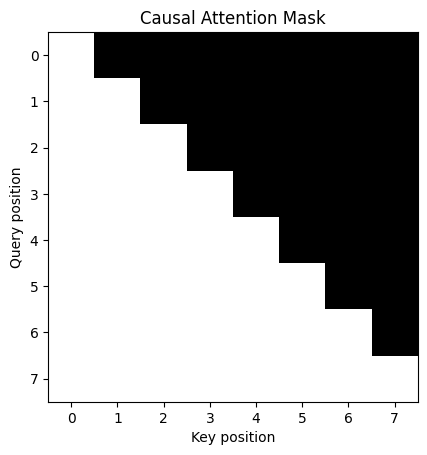

In [19]:
def create_causal_mask(sequence_length, device):
    #Replace the placeholder with a Boolean upper-triangular mask.
    return torch.triu(
        torch.ones(sequence_length, sequence_length, dtype = torch.bool, device = device),
        diagonal = 1,
    )

causal_mask = create_causal_mask(context_length, device)
print(causal_mask)
plt.imshow(causal_mask.cpu(), cmap="gray_r")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Causal Attention Mask")
plt.show()

## Part 3: Implement the Decoder Block

The decoder block must use masked self-attention, a residual connection and layer normalization, a feed-forward network, and a second residual connection and layer normalization.

In [23]:
class DecoderBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, feedforward_dim, dropout=0.1):
        super().__init__()
        #Define nn.MultiheadAttention with batch_first=True.
        self.self_attention = nn.MultiheadAttention( embedding_dim, num_heads,
                                                     batch_first = True)
        #Define norm1 and dropout1.
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.dropout1 = nn.Dropout(dropout)
        #Define feed_forward:
        self.feed_forward = nn.Sequential(
            nn.Linear(embedding_dim,feedforward_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(feedforward_dim, embedding_dim),
        )
        #Define norm2 and dropout2.
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        attention_output, _ = self.self_attention(
             x, x, x, attn_mask=causal_mask, need_weights=False
        )
        x = self.norm1(x + self.dropout1(attention_output))
        feedforward_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(feedforward_output))
        return x

## Part 4: Implement the Decoder-Only Transformer

Use token and positional embeddings, multiple decoder blocks, final layer normalization, and a linear vocabulary prediction layer. The forward method must return logits with shape:

~~~text
(batch_size, sequence_length, vocab_size)
~~~

In [24]:
class SimplifiedDecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_sequence_length,
        embedding_dim=64,
        num_heads=4,
        feedforward_dim=128,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        #Define token_embedding and position_embedding.
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        #Create a ModuleList containing num_layers DecoderBlock objects.
        self.position_embedding = nn.Embedding(max_sequence_length, embedding_dim)
        self.blocks = nn.ModuleList([
            DecoderBlock(embedding_dim, num_heads, feedforward_dim, dropout)
            for _ in range(num_layers)
        ])
        #Define final_norm and output_layer.
        self.final_norm = nn.LayerNorm(embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        position_ids = torch.arange(sequence_length, device=token_ids.device)
        position_ids = position_ids.unsqueeze(0).expand(batch_size, -1)
        x = self.token_embedding(token_ids) + self.position_embedding(position_ids)
        causal_mask = create_causal_mask(sequence_length, token_ids.device)
        for block in self.blocks:
            x = block(x, causal_mask)
        return self.output_layer(self.final_norm(x))

## Part 5: Instantiate and Inspect Your Model

In [29]:
embedding_dim = 64
num_heads = 4
feedforward_dim = 128
num_layers = 2
model = SimplifiedDecoderOnlyTransformer(
    vocab_size=vocab_size,
    max_sequence_length=context_length,
    embedding_dim=embedding_dim,
    num_heads=num_heads,
    feedforward_dim=feedforward_dim,
    num_layers=num_layers,
).to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

logits = model(example_x.to(device))
print("Logits shape:", tuple(logits.shape))

SimplifiedDecoderOnlyTransformer(
  (token_embedding): Embedding(123, 64)
  (position_embedding): Embedding(8, 64)
  (blocks): ModuleList(
    (0-1): 2 x DecoderBlock(
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (feed_forward): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=64, out_features=123, bias=True)
)
Trainable parameters: 83451
Logits shape: (16, 8

## Part 6: Complete the Training and Evaluation Functions

Use CrossEntropyLoss. Flatten logits from (batch, sequence, vocabulary) to (batch times sequence, vocabulary), and flatten targets to (batch times sequence).

In [32]:
def run_epoch(model, data_loader, criterion, device, optimizer=None):
    # Set training mode when optimizer is provided; otherwise evaluation mode.
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    # Loop over batches and move inputs and targets to device.
    # Compute logits, flattened cross-entropy loss, and token accuracy.
    # When optimizer is provided, zero gradients, backpropagate, and update.
    # Return average loss and accuracy.
    with torch.set_grad_enabled(training):
      for inputs, targets in data_loader:
          inputs, targets = inputs.to(device), targets.to(device)

          logits = model(inputs)
          loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

          if training:
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

          n = targets.numel()
          total_loss    += loss.item() * n
          total_correct += (logits.argmax(dim = -1) == targets).sum().item()
          total_tokens  += n
    return total_loss / total_tokens, total_correct / total_tokens

In [33]:
#Train for at least 50 epochs and record loss/accuracy histories.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_accuracy = run_epoch(
        model, train_loader, criterion, device, optimizer
    )
    val_loss, val_accuracy = run_epoch(
        model, val_loader, criterion, device
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"train loss={train_loss:.4f}, train accuracy={train_accuracy:.2%}, "
            f"validation loss={val_loss:.4f}, validation accuracy={val_accuracy:.2%}"
        )

Epoch 10: train loss=1.6126, train accuracy=77.96%, validation loss=1.8321, validation accuracy=64.19%
Epoch 20: train loss=0.4141, train accuracy=95.27%, validation loss=0.6599, validation accuracy=87.50%
Epoch 30: train loss=0.2078, train accuracy=95.19%, validation loss=0.4577, validation accuracy=90.20%
Epoch 40: train loss=0.1490, train accuracy=95.61%, validation loss=0.4282, validation accuracy=91.89%
Epoch 50: train loss=0.1298, train accuracy=95.44%, validation loss=0.4304, validation accuracy=91.22%
Epoch 60: train loss=0.1236, train accuracy=95.02%, validation loss=0.4442, validation accuracy=91.22%
Epoch 70: train loss=0.1073, train accuracy=95.69%, validation loss=0.4481, validation accuracy=91.89%
Epoch 80: train loss=0.1103, train accuracy=95.44%, validation loss=0.4590, validation accuracy=91.55%
Epoch 90: train loss=0.1040, train accuracy=95.61%, validation loss=0.4683, validation accuracy=91.55%
Epoch 100: train loss=0.1048, train accuracy=95.44%, validation loss=0.47

## Part 7: Plot Training and Validation Results

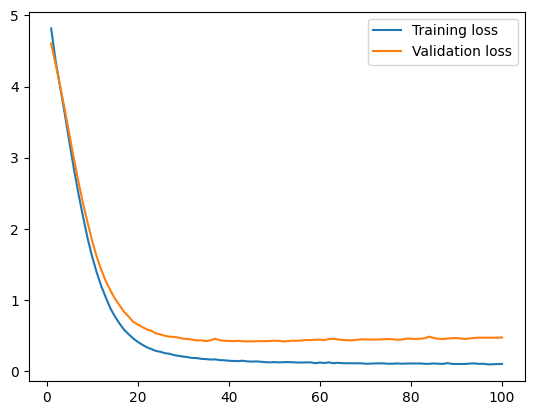

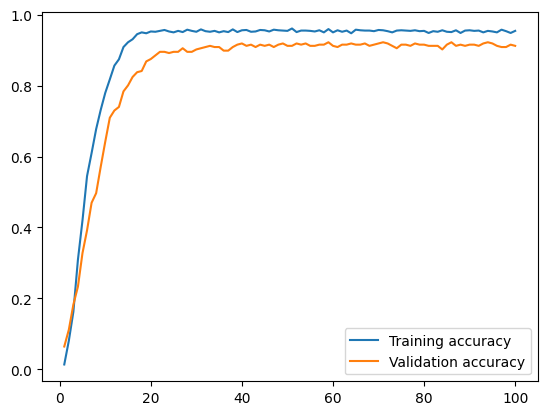

In [34]:
#Create and label one loss plot and one accuracy plot.

epochs = range(1, num_epochs + 1)
plt.plot(epochs, train_losses, label="Training loss")
plt.plot(epochs, val_losses, label="Validation loss")
plt.legend()
plt.show()

plt.plot(epochs, train_accuracies, label="Training accuracy")
plt.plot(epochs, val_accuracies, label="Validation accuracy")
plt.legend()
plt.show()

## Part 8: Generate Text from Three Prompts

In [36]:
def generate_text(model, seed_text, num_new_tokens=10):
    model.eval()
    # 1. Convert seed words to IDs.
    words = seed_text.lower().split()
    ids = [word_to_id.get(w, UNK_ID) for w in words]
    # 2. Keep at most context_length most recent IDs.
    # 3. Run the model and select the last-position next-token prediction.
    # 4. Append the predicted ID and repeat.
    # 5. Return decoded text.
    with torch.no_grad():
        for _ in range(num_new_tokens):
            window = ids[-context_length:]
            x = torch.tensor([window], device = device)
            logits = model(x)
            next_id = logits[0, -1].argmax().item()
            ids.append(next_id)
    return " ".join(id_to_word[i] for i in ids)

#Run generation with at least three prompts and include outputs.
prompts = ["the model", "attention helps", "language models"]
for prompt in prompts:
    print(prompt, "->", generate_text(model, prompt, num_new_tokens=10))

the model -> the model where tokens appear the model reads previous tokens before predicting
attention helps -> attention helps a model connect related words transformers process tokens with self
language models -> language models learn patterns from text data attention helps a model connect


## Part 9: Written Analysis

Answer all questions in the assignment description. Your PDF report must be 3–4 pages and include the causal-mask visualization, training plots, generated examples, and analysis.